<a href="https://colab.research.google.com/github/ARizalma/river-water-quality-analysis/blob/main/notebooks/04_water_quality_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Libraries

Import the libraries required for exploratory data analysis and visualization.

In [39]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Load Clean Dataset

Load the cleaned dataset generated during the preprocessing stage.

In [40]:
import requests

url = "https://raw.githubusercontent.com/ARizalma/river-water-quality-analysis/main/Data/river-water-quality-data-clean.csv"

df = pd.read_csv(url)

# Dataset Overview

Review the dataset dimensions and preview the cleaned data before analysis.

In [41]:
df.head()

,sampling_point,latitude,longitude,parameter_category,parameter_name,water_quality_standard,measurement_value,year,monitoring_period,sampling_month,river_name,location
0,ANK-1,-6.175882,106.728695,Fisika,TDS,1000,164.00,2023,Periode 1 (Musim Hujan),2,Angke,Jl. Duri Kosambi (Ciledug)
1,ANK-1,-6.175882,106.728695,Fisika,TSS,50,24.00,2023,Periode 1 (Musim Hujan),2,Angke,Jl. Duri Kosambi (Ciledug)
2,ANK-1,-6.175882,106.728695,Kimia,pH,6-9,7.56,2023,Periode 1 (Musim Hujan),2,Angke,Jl. Duri Kosambi (Ciledug)
3,ANK-1,-6.175882,106.728695,Kimia,BOD,3,23.65,2023,Periode 1 (Musim Hujan),2,Angke,Jl. Duri Kosambi (Ciledug)
4,ANK-1,-6.175882,106.728695,Kimia,COD,25,189.00,2023,Periode 1 (Musim Hujan),2,Angke,Jl. Duri Kosambi (Ciledug)


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10911 entries, 0 to 10910
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   sampling_point          10911 non-null  object 
 1   latitude                10911 non-null  float64
 2   longitude               10911 non-null  float64
 3   parameter_category      10911 non-null  object 
 4   parameter_name          10911 non-null  object 
 5   water_quality_standard  10911 non-null  object 
 6   measurement_value       10911 non-null  float64
 7   year                    10911 non-null  int64  
 8   monitoring_period       10911 non-null  object 
 9   sampling_month          10911 non-null  int64  
 10  river_name              10911 non-null  object 
 11  location                10911 non-null  object 
dtypes: float64(3), int64(2), object(7)
memory usage: 1023.0+ KB


In [43]:
df.shape

(10911, 12)

## Data Preparation for Analysis

In [44]:
def check_water_quality(row):

    value = row["measurement_value"]
    standard = row["water_quality_standard"]

    if "-" in str(standard):

        minimum, maximum = map(float, standard.split("-"))

        if minimum <= value <= maximum:
            return "Meets Standard"
        else:
            return "Exceeds Standard"

    else:

        if value <= float(standard):
            return "Meets Standard"
        else:
            return "Exceeds Standard"

In [45]:
df["status"] = df.apply(check_water_quality, axis=1)

In [46]:
df["water_quality_standard"].unique()

array(['1000', '50', '6-9', '3', '25', '4', '10', '0.06', '0.2', '1.5',
       '0.002', '0.03', '0.01', '0.05', '0.02', '1', '0.005', '5000'],
      dtype=object)

In [47]:
df[[
    "parameter_name",
    "measurement_value",
    "water_quality_standard",
    "status"
]].sample(10, random_state=50)

,parameter_name,measurement_value,water_quality_standard,status
6569,TSS,2.800000e+01,50,Meets Standard
7786,Fecal Coliform,3.000000e+06,1000,Exceeds Standard
6001,Total P,6.000000e-01,0.2,Exceeds Standard
9796,Total P,2.100000e-01,0.2,Exceeds Standard
3597,MBAS,6.000000e-02,0.2,Meets Standard
10246,Total Coliform,9.000000e+06,5000,Exceeds Standard
8792,Pb,1.900000e-02,0.03,Meets Standard
10597,COD,3.540000e+02,25,Exceeds Standard
8629,Zn,6.900000e-03,0.05,Meets Standard
7404,Total P,5.000000e-01,0.2,Exceeds Standard


In [48]:
df["status"].value_counts(normalize=True) * 100

,proportion
status,
Meets Standard,67.005774
Exceeds Standard,32.994226


## Water Quality Compliance Analysis

### Overall Compliance Distribution

In [49]:
status_counts = df["status"].value_counts()

status_counts

,count
status,
Meets Standard,7311
Exceeds Standard,3600


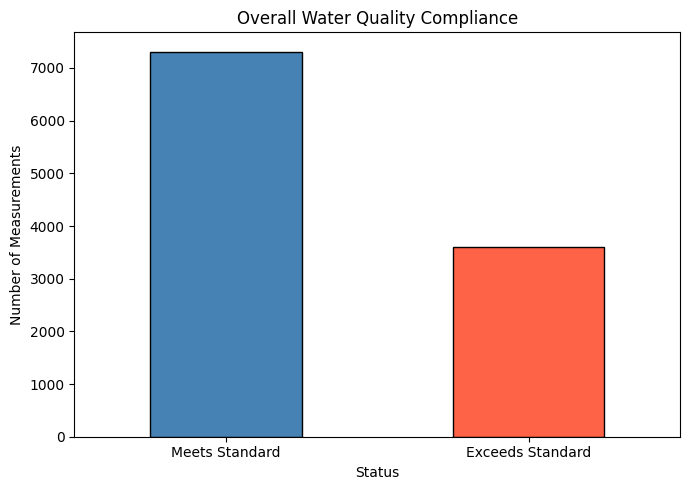

In [50]:
plt.figure(figsize=(7,5))

status_counts.plot(
    kind="bar",
    color=["steelblue", "tomato"],
    edgecolor="black"
)

plt.title("Overall Water Quality Compliance")
plt.xlabel("Status")
plt.ylabel("Number of Measurements")

plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "overall_water_quality_compliance.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Compliance Percentage

In [51]:
status_percentage = (
    df["status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

status_percentage

,proportion
status,
Meets Standard,67.01
Exceeds Standard,32.99


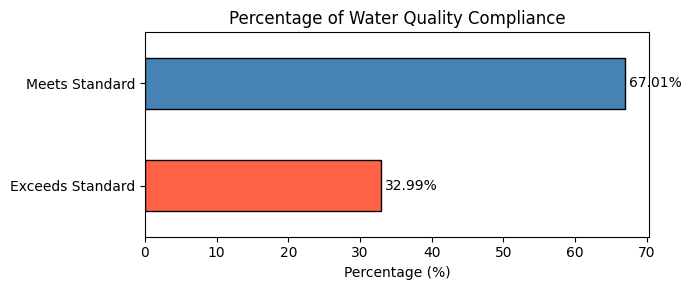

In [52]:
plt.figure(figsize=(7,3))

status_percentage.sort_values().plot(
    kind="barh",
    color=["tomato", "steelblue"],
    edgecolor="black"
)

plt.title("Percentage of Water Quality Compliance")
plt.xlabel("Percentage (%)")
plt.ylabel("")

for index, value in enumerate(status_percentage.sort_values()):
    plt.text(
        value + 0.5,
        index,
        f"{value:.2f}%",
        va="center"
    )

plt.tight_layout()

plt.savefig(
    "percentage_of_water_quality_compliance",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## River Quality Analysis

This section analyzes water quality conditions across different rivers.

The objective is to identify rivers with the highest and lowest compliance with environmental quality standards, compare monitoring intensity among rivers, and explore whether specific locations show consistent patterns of water quality issues.

### Measurement Distribution by River

In [53]:
river_measurements = (
    df["river_name"]
    .value_counts()
    .sort_values(ascending=False)
)

river_measurements.head(10)

,count
river_name,
Ciliwung,1656
Kalibaru Timur,920
Sunter,736
Cipinang,644
Cideng,556
Kalibaru Barat,552
Mampang,552
Grogol,552
Cakung,490


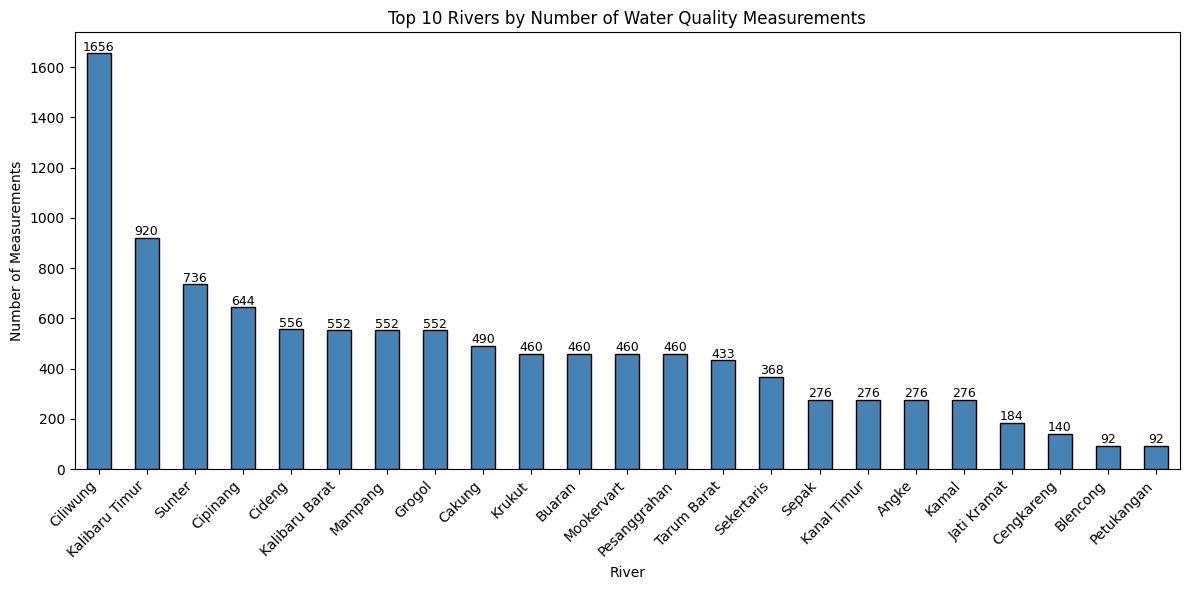

In [54]:
plt.figure(figsize=(12,6))

ax = river_measurements.plot(
    kind="bar",
    color="steelblue",
    edgecolor="black"
)

for i, value in enumerate(river_measurements):
    ax.text(
        i,
        value + 10,
        str(value),
        ha="center",
        fontsize=9
    )

plt.title("Top 10 Rivers by Number of Water Quality Measurements")
plt.xlabel("River")
plt.ylabel("Number of Measurements")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.savefig(
    "measurement_distribution_by_river.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Compliance Percentage by River

In [55]:
river_status = (
    df.groupby(["river_name", "status"])
      .size()
      .unstack(fill_value=0)
)

river_percentage = (
    river_status.div(
        river_status.sum(axis=1),
        axis=0
    ) * 100
)

river_percentage.head()

status,Exceeds Standard,Meets Standard
river_name,,
Angke,31.159420,68.840580
Blencong,38.043478,61.956522
Buaran,35.000000,65.000000
Cakung,37.346939,62.653061
Cengkareng,32.142857,67.857143


In [56]:
river_percentage = (
    river_percentage
    .sort_values(
        by="Exceeds Standard",
        ascending=False
    )
)

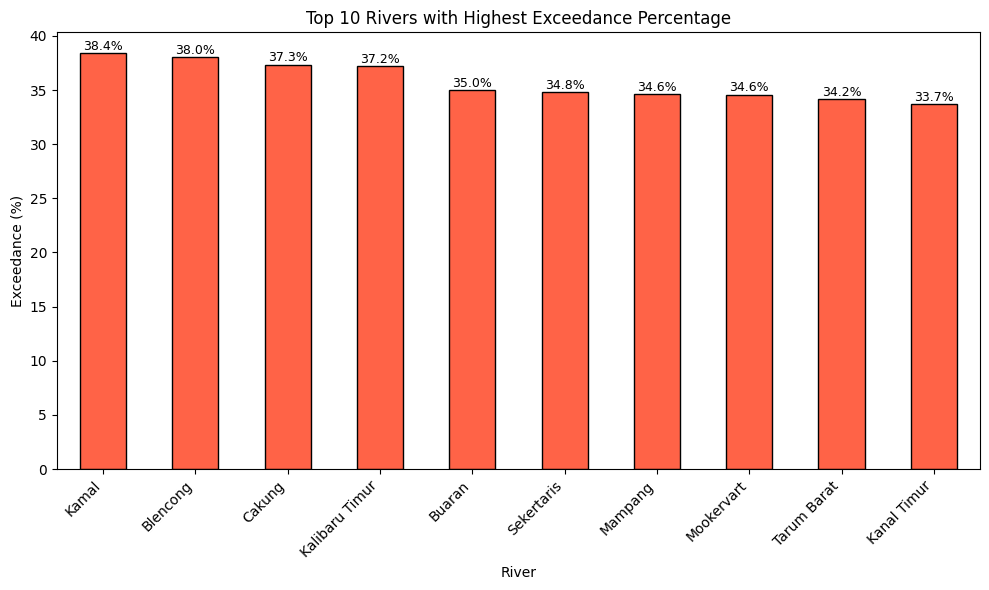

In [57]:
top10 = river_percentage.head(10)

plt.figure(figsize=(10,6))

ax = top10["Exceeds Standard"].plot(
    kind="bar",
    color="tomato",
    edgecolor="black"
)

for i, value in enumerate(top10["Exceeds Standard"]):
    ax.text(
        i,
        value + 0.3,
        f"{value:.1f}%",
        ha="center",
        fontsize=9
    )

plt.title("Top 10 Rivers with Highest Exceedance Percentage")
plt.xlabel("River")
plt.ylabel("Exceedance (%)")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.savefig(
    "top10_rivers_exceedance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [58]:
river_percentage["Exceeds Standard"].describe()

,Exceeds Standard
count,23.000000
mean,33.326851
std,2.812574
min,28.260870
25%,31.136775
50%,33.633094
75%,34.692029
max,38.405797


### Top 10 Rivers with Highest Exceedance

This analysis identifies the rivers with the highest proportion of measurements exceeding the environmental quality standards.

Ranking rivers based on exceedance percentage helps prioritize locations that may require closer monitoring and pollution control measures.

In [59]:
top10_exceedance = (
    river_percentage["Exceeds Standard"]
    .sort_values(ascending=False)
    .head(10)
)

top10_exceedance

,Exceeds Standard
river_name,
Kamal,38.405797
Blencong,38.043478
Cakung,37.346939
Kalibaru Timur,37.173913
Buaran,35.000000
Sekertaris,34.782609
Mampang,34.601449
Mookervart,34.565217
Tarum Barat,34.180139


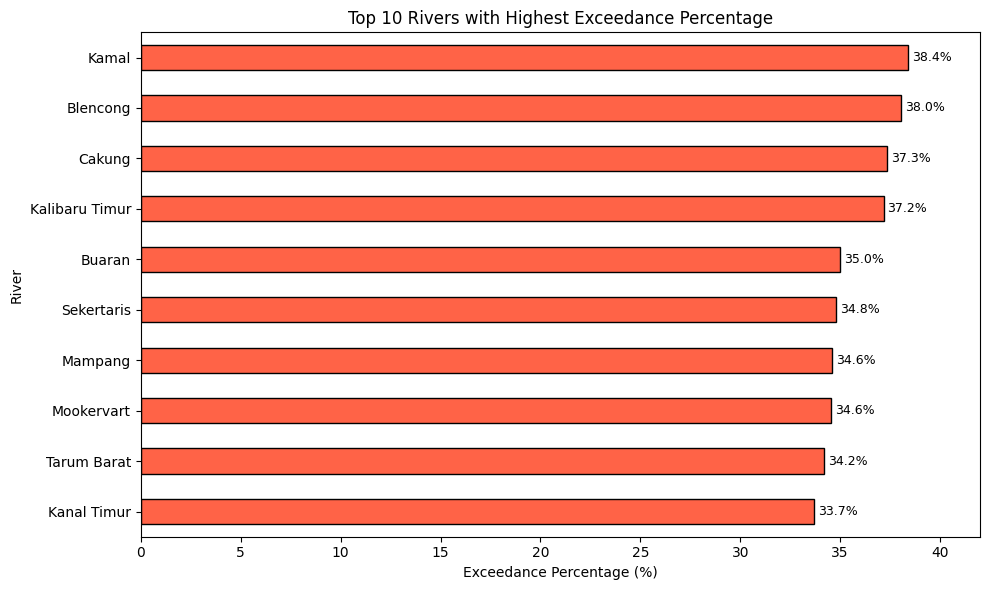

In [62]:
plt.figure(figsize=(10,6))

ax = top10_exceedance.plot(
    kind="barh",
    color="tomato",
    edgecolor="black"
)

ax.invert_yaxis()

for i, value in enumerate(top10_exceedance):
    ax.text(
        value + 0.2,
        i,
        f"{value:.1f}%",
        va="center",
        fontsize=9
    )

plt.title("Top 10 Rivers with Highest Exceedance Percentage")
plt.xlabel("Exceedance Percentage (%)")
plt.ylabel("River")

plt.xlim(0,42)

plt.tight_layout()

plt.savefig(
    "top10_rivers_highest_exceedance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Top 10 Rivers with Highest Compliance

This analysis highlights the rivers with the highest proportion of measurements meeting environmental quality standards.

Identifying well-performing rivers can help recognize effective water quality management practices and provide useful references for improving conditions in other rivers.

In [63]:
top10_compliance = (
    river_percentage["Meets Standard"]
    .sort_values(ascending=False)
    .head(10)
)

top10_compliance

,Meets Standard
river_name,
Krukut,71.739130
Pesanggrahan,71.086957
Cipinang,70.341615
Jati Kramat,69.565217
Ciliwung,69.384058
Sunter,68.885870
Angke,68.840580
Cengkareng,67.857143
Petukangan,67.391304


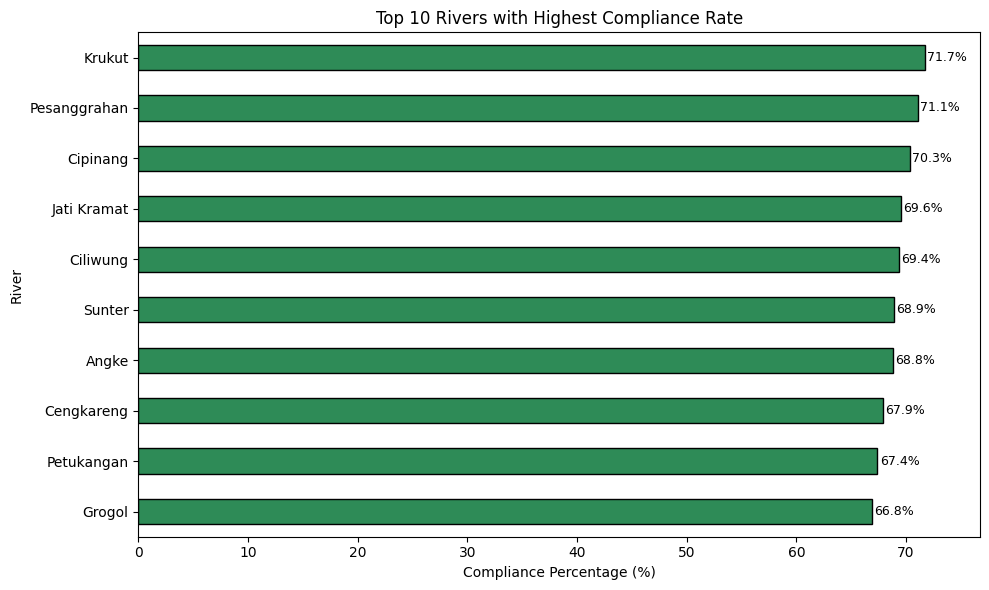

In [66]:
plt.figure(figsize=(10,6))

ax = top10_compliance.plot(
    kind="barh",
    color="seagreen",
    edgecolor="black"
)

ax.invert_yaxis()

for i, value in enumerate(top10_compliance):
    ax.text(
        value + 0.2,
        i,
        f"{value:.1f}%",
        va="center",
        fontsize=9
    )

plt.title("Top 10 Rivers with Highest Compliance Rate")
plt.xlabel("Compliance Percentage (%)")
plt.ylabel("River")

plt.xlim(0, top10_compliance.max() + 5)

plt.tight_layout()

plt.savefig(
    "top10_rivers_highest_compliance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Dominant Exceeding Parameters by River